In [1]:
import pandas as pd

In [2]:
housing = pd.read_csv("housing.csv")

In [3]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

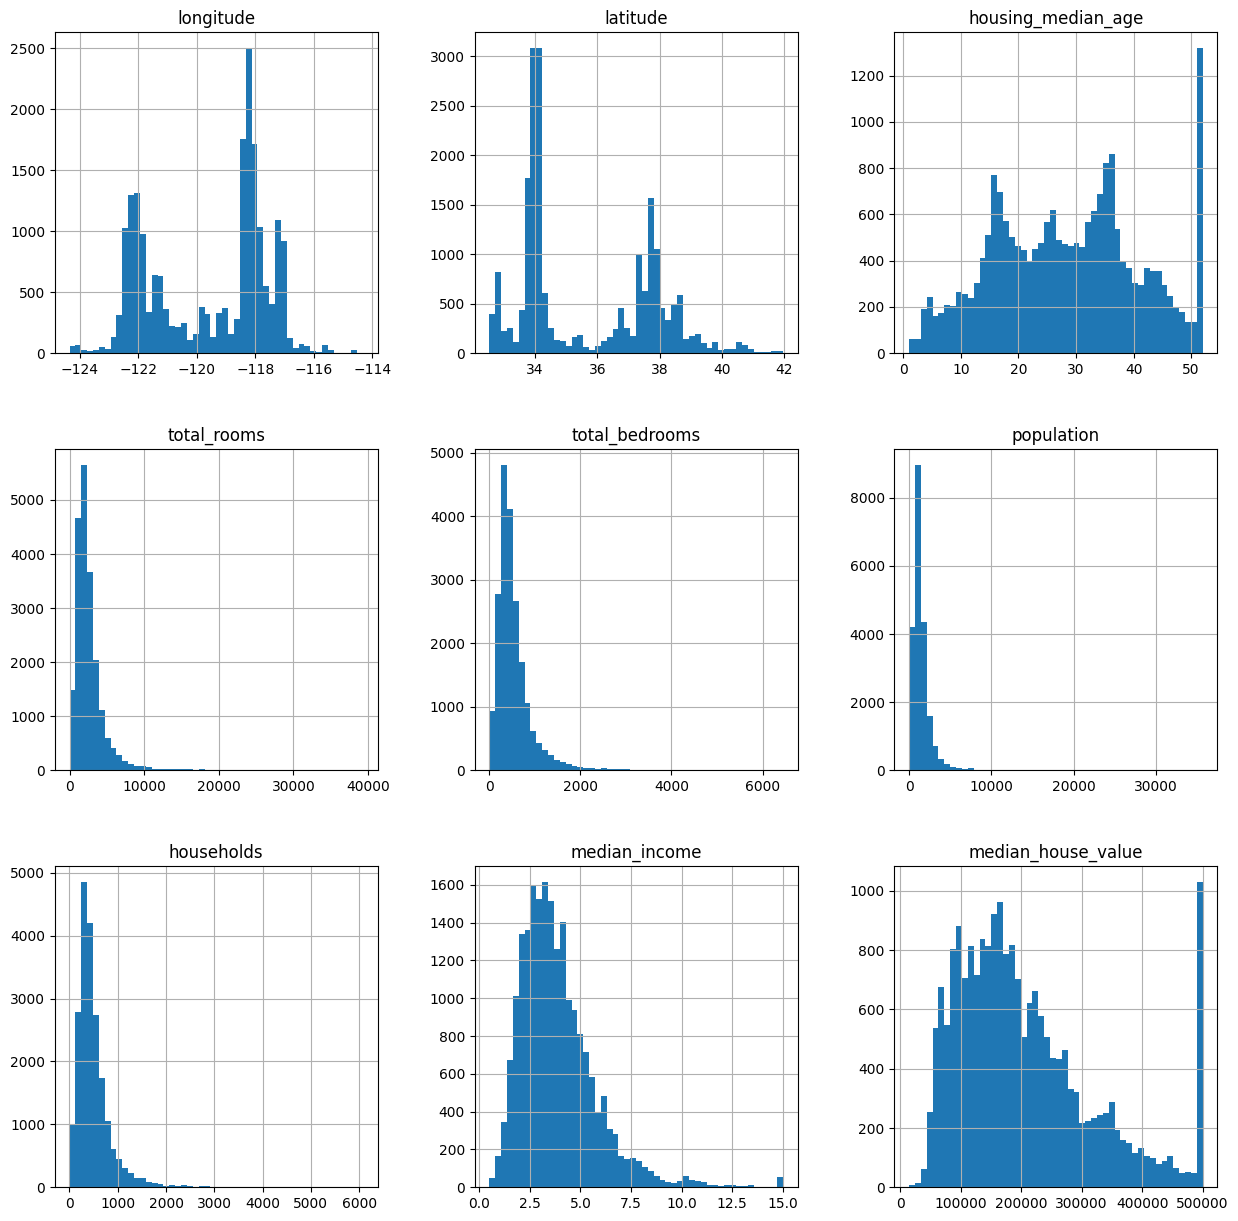

In [4]:
import matplotlib.pyplot as plt
housing.hist(bins = 50, figsize = (15,15))  #pandas ploting working on matplotlib

<Axes: >

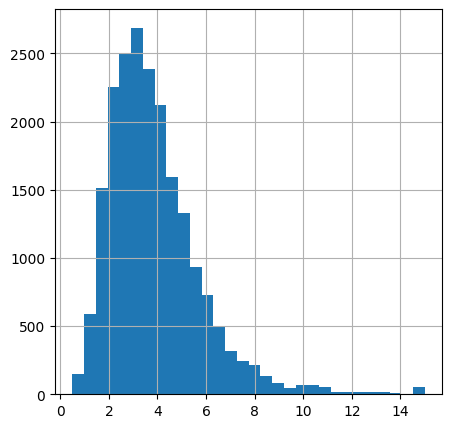

In [5]:
housing['median_income'].hist(bins = 30, figsize = (5,5))

Create a test set

In [6]:
import numpy as np

In [7]:
#This function is not reliable as the test set changes because of the random permutation.
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = split_train_test(housing, 0.2)
#train_set
#len(test_set)

<h2 style="text-align: left; red: blue;">Using hash functions to split a dataset</h2>

In [8]:
from zlib import crc32
def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_,test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [9]:
housing_id = housing.reset_index()
housing_id.head() #with an id column called "index" which is used as a unique identifier.
train_set, test_set = split_train_test_by_id(housing_id, 0.2,"index")
#train_set
#test_set

In [10]:
housing_id['id'] = housing['longitude'] * 1000 + housing['latitude']
housing_id #with an id column called 'id' which is used as a unique identifier
train_set, test_set = split_train_test_by_id(housing_id, 0.2,"id")
#train_set
#test_set

<h2 style="text-align: left; red: blue;">Using Scikit-Learn to split dataset</h2>

In [11]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size = 0.2,random_state = 42)
#train_set
#test_set

/tmp/ipykernel_5363/45379878.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  housing['income_cat'].where(housing['income_cat'] < 5, 5.0, inplace = True)


<Axes: >

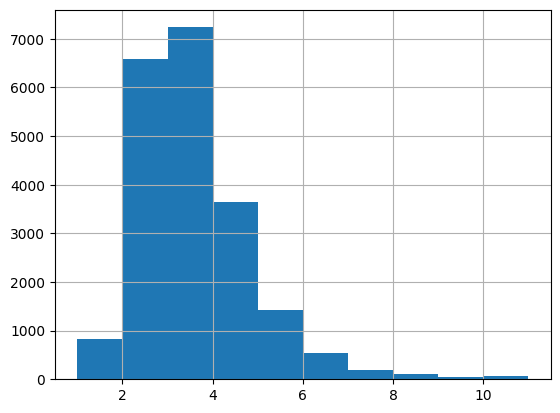

In [12]:
housing['income_cat'] = np.ceil(housing['median_income']/1.5)
housing['income_cat'].where(housing['income_cat'] < 5, 5.0, inplace = True)
housing['income_cat'].hist()

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

In [14]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]


for set_ in (strat_test_set,strat_train_set):
    set_.drop('income_cat',axis= 1, inplace = True)

In [15]:
housing_labels = strat_train_set['median_house_value'].copy()

<h2 style="text-align: left; red: blue;">Visualizing The Data</h2>

In [16]:
housing = strat_train_set.copy()

Text(0.5, 1.0, 'Alpha = 0.1 (Density Visible)')

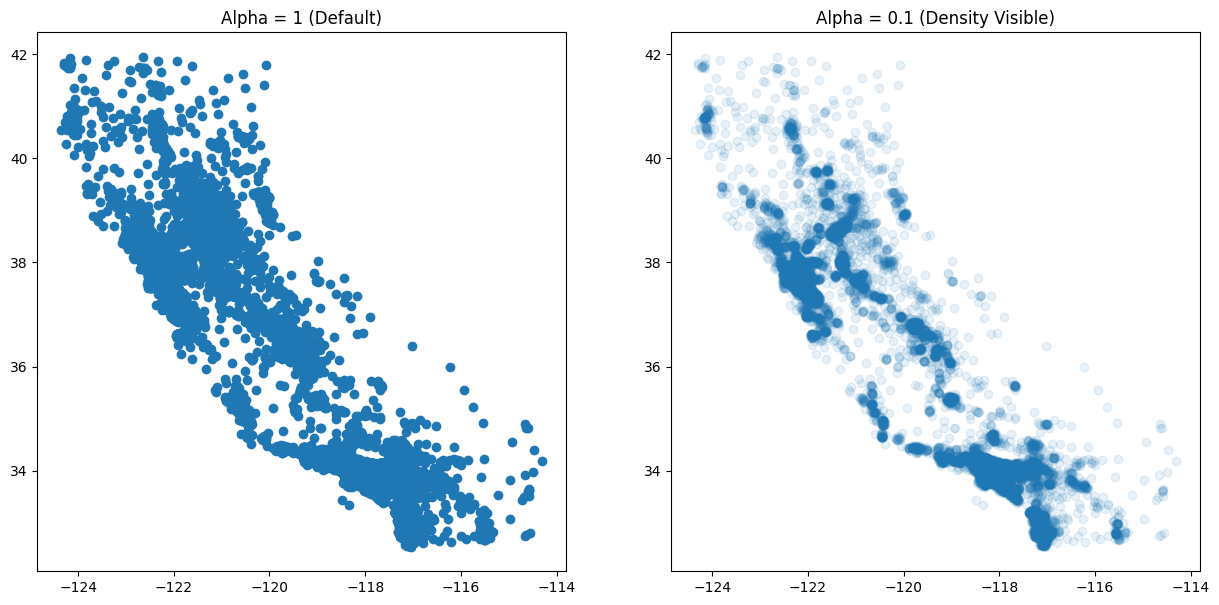

In [17]:
fig, ax = plt.subplots(1,2,figsize=(15,7))
ax[0].scatter(housing['longitude'],housing['latitude'])
ax[0].set_title("Alpha = 1 (Default)")
ax[1].scatter(housing['longitude'],housing['latitude'],alpha = 0.1)
ax[1].set_title("Alpha = 0.1 (Density Visible)")

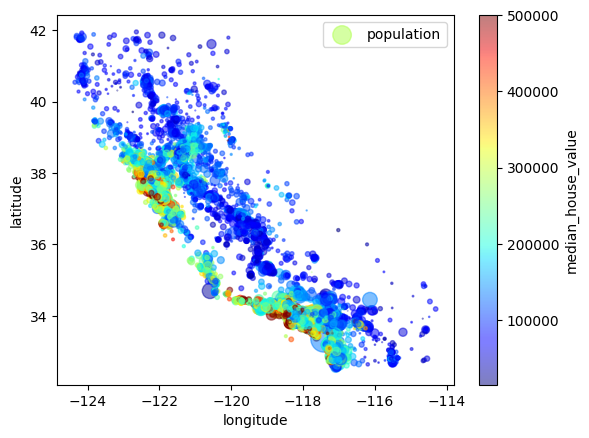

In [18]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.5,
             s=housing["population"]/100, label="population", 
             c="median_house_value", cmap="jet", 
             colorbar=True)
plt.legend()

<h2 style="text-align: left; red: blue;">CORRELATION</h2>

In [19]:
corr_matrix = housing.corr(numeric_only = True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687474
total_rooms           0.135989
housing_median_age    0.111770
households            0.065841
total_bedrooms        0.049177
population           -0.024765
longitude            -0.045056
latitude             -0.144684
Name: median_house_value, dtype: float64

In [20]:
from pandas.plotting import scatter_matrix  #scatter matrix is used to draw correlation among features of a dataset.

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

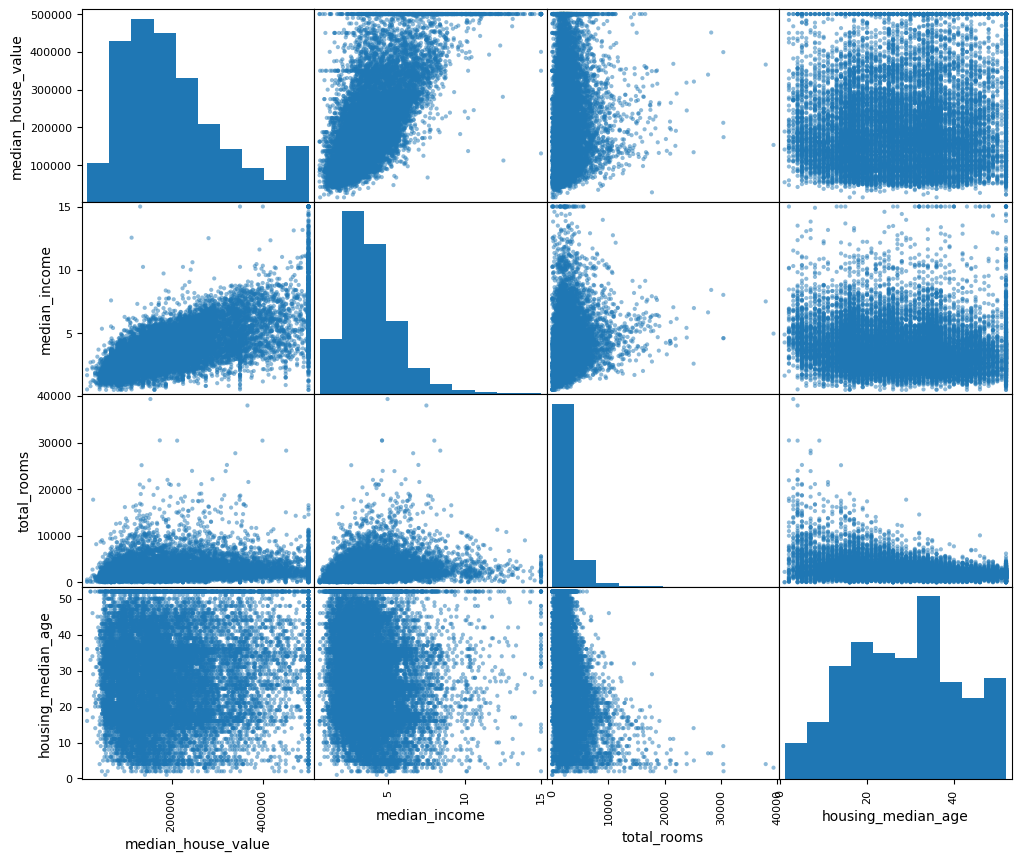

In [21]:
attributes = ['median_house_value', 'median_income','total_rooms', 'housing_median_age']
scatter_matrix(housing[attributes], figsize=(12,10))

<Axes: xlabel='median_income', ylabel='median_house_value'>

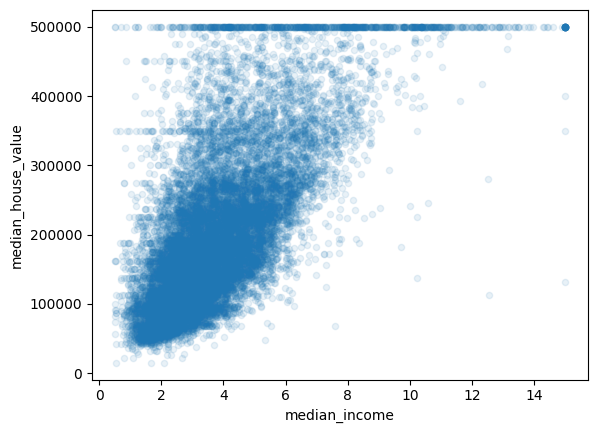

In [22]:
housing.plot(kind = "scatter", x = "median_income",y ="median_house_value",alpha = 0.1)

In [23]:
housing['rooms_per_household'] = housing['total_rooms']/housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms']/housing['total_rooms']
housing['population_per_household'] = housing['population']/housing['households']

In [24]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,286600.0,<1H OCEAN,4.625369,0.223852,2.094395
15698,-122.46,37.79,52.0,899.0,96.0,304.0,110.0,14.2959,500001.0,NEAR BAY,8.172727,0.106785,2.763636
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,196900.0,NEAR OCEAN,4.225108,0.241291,2.025974
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,46300.0,INLAND,5.232295,0.200866,4.135977
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,254500.0,<1H OCEAN,4.505810,0.231341,3.047847


In [25]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687474
rooms_per_household         0.145750
total_rooms                 0.135989
housing_median_age          0.111770
households                  0.065841
total_bedrooms              0.049177
population_per_household   -0.021844
population                 -0.024765
longitude                  -0.045056
latitude                   -0.144684
bedrooms_per_room          -0.259679
Name: median_house_value, dtype: float64

<h2 style="text-align: left; red: blue;">DATA CLEANING </h2>

In [26]:
#Dealing with null values
housing.isnull().any()
housing.dropna(subset=['total_bedrooms']) #(option 1) Get rid of corresponding districts
housing.drop('total_bedrooms',axis = 1) #(option 2) Dropping entire column
median = housing['total_bedrooms'].median()
housing.fillna(median, inplace = True) #(option 3) filling the null values with                                                                    #the median of the total bedroom column

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,286600.0,<1H OCEAN,4.625369,0.223852,2.094395
15698,-122.46,37.79,52.0,899.0,96.0,304.0,110.0,14.2959,500001.0,NEAR BAY,8.172727,0.106785,2.763636
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,196900.0,NEAR OCEAN,4.225108,0.241291,2.025974
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,46300.0,INLAND,5.232295,0.200866,4.135977
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,254500.0,<1H OCEAN,4.505810,0.231341,3.047847
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6563,-118.13,34.20,46.0,1271.0,236.0,573.0,210.0,4.9312,240200.0,INLAND,6.052381,0.185681,2.728571
12053,-117.56,33.88,40.0,1196.0,294.0,1052.0,258.0,2.0682,113000.0,INLAND,4.635659,0.245819,4.077519
13908,-116.40,34.09,9.0,4855.0,872.0,2098.0,765.0,3.2723,97800.0,INLAND,6.346405,0.179609,2.742484
11159,-118.01,33.82,31.0,1960.0,380.0,1356.0,356.0,4.0625,225900.0,<1H OCEAN,5.505618,0.193878,3.808989


In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')
housing_num = housing.drop('ocean_proximity',axis = 1)
X = imputer.fit_transform(housing_num) 

In [28]:
housing_transform = pd.DataFrame(X, columns = housing_num.columns)
housing_transform.isnull().any()

longitude                   False
latitude                    False
housing_median_age          False
total_rooms                 False
total_bedrooms              False
population                  False
households                  False
median_income               False
median_house_value          False
rooms_per_household         False
bedrooms_per_room           False
population_per_household    False
dtype: bool

<h2 style="text-align: left; red: blue;"> Text and Categorical Attributes</h2andling 

In [29]:
housing_cat = housing[['ocean_proximity']]#The [[]] makes it a DataFrame whiles [] makes it a series 
housing_cat.head(10)

,ocean_proximity
17606,<1H OCEAN
15698,NEAR BAY
14650,NEAR OCEAN
3230,INLAND
3555,<1H OCEAN
19480,INLAND
9026,NEAR OCEAN
13685,INLAND
4937,<1H OCEAN
4861,<1H OCEAN


In [30]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()  #ordinal_encoder is an instance of the class OrdinalEncoder and also it's an estimator
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]
#ordinal_encoder.categories_ #categories_ is a parameter(Learned Attributes)

array([[0.],
       [3.],
       [4.],
       [1.],
       [0.],
       [1.],
       [4.],
       [1.],
       [0.],
       [0.]])

In [31]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder =  OneHotEncoder(handle_unknown='ignore')
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot
housing_cat_1hot.toarray() #convert the sparse matrix from OneHotEncoder to a numpy array
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

<h2 style="text-align: left; red: blue;"> Feature Scaling</h2andling 

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [33]:
scaler = MinMaxScaler() #Used to shift ranges of data between (0,1) or maybe (0,..)
housing_scale = scaler.fit_transform(housing_num)
df_housing_scale = pd.DataFrame(housing_scale,columns = housing_num.columns)
#df_housing_scale

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
standard_scaler = StandardScaler()
housing_num_standardized = standard_scaler.fit_transform(housing_num)
df_housing_num_standardized  = pd.DataFrame(housing_num_standardized, columns = housing_num.columns)
#df_housing_num_standardized

<h2 style="text-align: left; red: blue;"> Transformation Pipelines</h2andling 

In [36]:
from sklearn.pipeline import Pipeline

In [37]:
num_pipeline = Pipeline([('imputer',SimpleImputer(strategy = 'mean')), #Dealing with missing values
                         ('minmaxscaler',MinMaxScaler(feature_range=(0,1)))])  #feature scaling 
housing_num_tr = num_pipeline.fit_transform(housing_num)
df_housing_num_tr = pd.DataFrame(housing_num_tr, columns = housing_num.columns)
#df_housing_num_tr

In [38]:
from sklearn.compose import ColumnTransformer

num_attributes = list(housing_num)
cat_attributes = ['ocean_proximity']

full_pipeline = ColumnTransformer([('numeric',num_pipeline,num_attributes),
                                   ('text',OneHotEncoder(),cat_attributes)])

housing_prepared = full_pipeline.fit_transform(housing)
list1 = list(housing_num)
list2 = ['c1','c2','c3','c4','c5']
Columns = list1 + list2
df_housing_prepared = pd.DataFrame(housing_prepared, columns = Columns)
#df_housing_prepared

<h2 style="text-align: left; red: blue;"> Model Selection and Training</h2andling 

<h3 style="text-align: left; red: blue;">Linear Regression</h3andling 

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
#Some example to help understand things happening here.
random_data = housing.iloc[:5]
random_labels = housing_labels.iloc[:5]
random_data_prepared = full_pipeline.transform(random_data)
print(f"Predictions: {lin_reg.predict(random_data_prepared)}")
print(f"Labels: {list(random_labels)}")

Predictions: [286600. 500001. 196900.  46300. 254500.]
Labels: [286600.0, 500001.0, 196900.0, 46300.0, 254500.0]


In [42]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels,housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(2.3066357158155958e-09)

<h3 style="text-align: left; red: blue;"> Decision Tree Regressor</h3andling 

In [43]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)
housing_predictions = tree_reg.predict(housing_prepared)

tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

<h3 style="text-align: left; red: blue;"> Random Forest Regressor</h3andling 

In [44]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)
housing_predictions = forest_reg.predict(housing_prepared)

forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse


np.float64(39.62641263682781)

<h3 style="text-align: left; red: blue;"> Better Evaluation Using Cross-Validation</h3andling 

In [45]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg,housing_prepared,housing_labels,
                         scoring='neg_mean_squared_error',cv =10)

tree_rmse_scores = np.sqrt(-scores) #note the (-) infront of the scores because scikit uses the concept of 
                                    #greater is better whiles in rmse lesser error is better 
                                    #so in other to get the correct value we multiple it by a *-(negative)*


In [46]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores) #cross validation of Decision Tree Regressor model

Scores: [ 88.16119948  80.36689475  96.17140966 115.19871962  87.91273687
 215.39056548 216.40054305 223.11190571  96.92423062  85.04105254]
Mean: 130.46792578031778
Standard deviation: 58.213634947761406


In [47]:
lin_scores = cross_val_score(lin_reg,housing_prepared,housing_labels,
                             scoring = 'neg_mean_squared_error',cv = 10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores) #cross validation of Linear Regression model

Scores: [1.30581353e-09 1.28925776e-09 1.33753236e-09 1.23184494e-09
 1.57737322e-09 1.54423244e-09 1.71752197e-09 1.87320344e-09
 2.03359487e-09 1.88957545e-09]
Mean: 1.5799949979927449e-09
Standard deviation: 2.733978422463549e-10


In [48]:
forest_scores = cross_val_score(forest_reg,housing_prepared, housing_labels,
                                 scoring = 'neg_mean_squared_error',cv = 10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [ 38.67992401  84.64817989  48.09029878  80.30336886  50.21764237
 186.0781348   86.21127145 119.6638278   51.99173035  72.94189115]
Mean: 81.88262694710366
Standard deviation: 41.59022864390275


### Using Joblib to save models

In [49]:
import joblib
models_trained = {
    'model_1': lin_reg,
    'model_2': tree_reg,
    'model_3': forest_reg
}
joblib.dump(models_trained,'Trained_models.pkl')

['Trained_models.pkl']

In [50]:
loaded = joblib.load('Trained_models.pkl')
print(loaded['model_2'])

DecisionTreeRegressor()


### Fine-Tune Your Model

#### Grid Search

In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
param_grid = [
    {'n_estimators':[3,10,30,40], 'max_features':[2,4,6,8]},
    {'bootstrap':[False],'n_estimators':[3,10],'max_features':[2,3,4]}
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True
                          )
grid_search.fit(housing_prepared,housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [53]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres['mean_test_score'],cvres['params']):
    print(np.sqrt(-mean_score),params)

36380.658798198376 {'max_features': 2, 'n_estimators': 3}
22870.144767098896 {'max_features': 2, 'n_estimators': 10}
22930.91392897213 {'max_features': 2, 'n_estimators': 30}
22181.299588931684 {'max_features': 2, 'n_estimators': 40}
16249.229651373933 {'max_features': 4, 'n_estimators': 3}
12984.050013324879 {'max_features': 4, 'n_estimators': 10}
10025.410372725919 {'max_features': 4, 'n_estimators': 30}
9705.444550068667 {'max_features': 4, 'n_estimators': 40}
11606.530292858686 {'max_features': 6, 'n_estimators': 3}
6306.752465855778 {'max_features': 6, 'n_estimators': 10}
5096.018584747528 {'max_features': 6, 'n_estimators': 30}
4967.8689538980025 {'max_features': 6, 'n_estimators': 40}
6581.847551555825 {'max_features': 8, 'n_estimators': 3}
4046.6921994205823 {'max_features': 8, 'n_estimators': 10}
2539.707520537821 {'max_features': 8, 'n_estimators': 30}
2549.824165788921 {'max_features': 8, 'n_estimators': 40}
29353.945346856897 {'bootstrap': False, 'max_features': 2, 'n_estim

#### Analyze the best models and their errors

In [54]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([3.39727985e-03, 2.94724779e-03, 4.15217142e-03, 7.69180681e-04,
       6.72824517e-04, 4.72356516e-04, 7.06029874e-04, 1.57453922e-01,
       7.51067804e-01, 8.56120583e-03, 1.33558533e-02, 1.39401203e-02,
       7.27211456e-03, 3.37296580e-02, 3.86276354e-05, 1.39986617e-03,
       6.37377781e-05])

In [55]:
extra_attibs = ['rooms_per_hhold','pop_per_hhold','bedrooms_per_room']
cat_encoder = full_pipeline.named_transformers_["text"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes =  extra_attibs + cat_one_hot_attribs
attributes
sorted(zip(feature_importances,attributes), reverse= True)

[(np.float64(0.15745392226929353), 'NEAR OCEAN'),
 (np.float64(0.004152171420940342), 'bedrooms_per_room'),
 (np.float64(0.0033972798547402218), 'rooms_per_hhold'),
 (np.float64(0.0029472477887615405), 'pop_per_hhold'),
 (np.float64(0.0007691806806985674), '<1H OCEAN'),
 (np.float64(0.0007060298738430223), 'NEAR BAY'),
 (np.float64(0.0006728245166937845), 'INLAND'),
 (np.float64(0.000472356516095448), 'ISLAND')]

### Evaluate your system on the test set

In [56]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop('median_house_value',axis = 1)
y_test = strat_test_set['median_house_value'].copy()

X_test_prepared = full_pipeline.transform(X_test)


final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

ValueError: columns are missing: {'rooms_per_household', 'median_house_value', 'population_per_household', 'bedrooms_per_room'}

#### Confidence Interval

In [ ]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test)**2
np.sqrt(stats.t.interval(confidence, len(squared_errors)-1,
                         loc = squared_errors.mean(),
                         scale = stats.sem(squared_errors)))